# RNN — TensorFlow Pipeline

## Model: Recurrent Neural Network (Vanilla RNN + GRU)
- **Dataset**: ECG5000 — 4,000 train / 1,000 test, 140 timesteps, 5 heartbeat classes
- **Task**: Classify heartbeat arrhythmias (severe class imbalance: 121.6x ratio)
- **Framework showcase**: Keras Sequential API (SimpleRNN/GRU layers), model.fit with class_weight, GradientTape for gradient analysis
- **Device**: CPU (Windows) — ECG5000 trains in seconds, WSL2 GPU unnecessary

## Evaluation Strategy
- **Primary metric**: Macro F1 (not accuracy — 58% majority class makes accuracy misleading)
- **Training curves**: Loss + accuracy (train/val)
- **Gradient analysis**: Per-layer gradient norms comparing vanilla RNN vs GRU

## Pipeline
1. Load data + config
2. Vanilla RNN baseline
3. Vanishing gradient demonstration
4. GRU model (gated fix)
5. Architecture sweep (hidden size, depth, bidirectional)
6. Best model full evaluation
7. Benchmarks
8. Save results + cross-framework comparison

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import tensorflow as tf
from tensorflow import keras
import time
import sys
sys.path.append('../..')

from utils.data_loader import load_processed_data
from utils.metrics import evaluate_classifier, macro_f1_score
from utils.visualization import (plot_training_history,
                                  plot_confusion_matrix_multiclass,
                                  plot_gradient_flow,
                                  plot_ecg_predictions,
                                  plot_hidden_state_evolution)
from utils.performance import track_performance, track_inference, get_model_size
from utils.results import build_results_dict, save_results, add_result, print_comparison
from utils.rnn_utils import compute_gradient_norms

# Config
RANDOM_STATE = 113
FRAMEWORK = "TensorFlow"
MODEL_NAME = "RNN"
BATCH_SIZE = 64
N_CLASSES = 5
N_FEATURES = 1
SEQ_LEN = 140

tf.random.set_seed(RANDOM_STATE)

# Detect device
gpus = tf.config.list_physical_devices('GPU')
device_name = gpus[0].name if gpus else "CPU"

# Load data
X_train, X_test, y_train, y_test, metadata = load_processed_data('rnn')

CLASS_NAMES = metadata['class_names']
class_weights = {int(k): v for k, v in metadata['class_weights'].items()}

# Ensure float32
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

# Results directory
os.makedirs('results', exist_ok=True)

# Step 1:
print("=" * 60)
print(f"[1/8] {FRAMEWORK} — {MODEL_NAME} Pipeline")
print("=" * 60)
print(f"Device: {'GPU' if gpus else 'CPU'} ({device_name})")
print(f"TF version: {tf.__version__}")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Sequence: {SEQ_LEN} timesteps x {N_FEATURES} feature")
print(f"Classes: {N_CLASSES} ({', '.join(CLASS_NAMES)})")
print(f"Batch size: {BATCH_SIZE}")
print(f"Class weights: {[f'{v:.2f}' for v in class_weights.values()]}")

[1/8] TensorFlow — RNN Pipeline
Device: CPU (CPU)
TF version: 2.20.0
Train: (4000, 140, 1) | Test: (1000, 140, 1)
Sequence: 140 timesteps x 1 feature
Classes: 5 (Normal, R-on-T PVC, PVC, SP, UB)
Batch size: 64
Class weights: ['0.34', '0.57', '10.39', '5.16', '42.11']


In [2]:
# Step 2: Vanilla RNN Baseline
"""
keras.layers.SimpleRNN — Keras equivalent of nn.RNN.
Uses model.fit() with class_weight dict for imbalanced data.
EarlyStopping on val macro F1 via custom callback.
Expect similar results to PT: ~85% accuracy, ~0.49 macro F1.
"""

print("=" * 60)
print("[2/8] Vanilla RNN — Baseline")
print("=" * 60)


class MacroF1Callback(keras.callbacks.Callback):
    """
    Track validation macro F1 for early stopping.

    Keras EarlyStopping only monitors built-in metrics.
    This callback computes macro F1 each epoch and stores
    the best model weights.

    Args:
        X_val: Validation input array.
        y_val: Validation labels.
        patience: Epochs to wait after best F1.
    """
    def __init__(self, X_val, y_val, patience=10):
        super().__init__()
        self.X_val = X_val
        self.y_val = y_val
        self.patience = patience
        self.best_f1 = 0.0
        self.wait = 0
        self.best_weights = None
        self.val_f1s = []

    def on_epoch_end(self, epoch, logs=None):
        preds = np.argmax(self.model.predict(self.X_val, verbose=0), axis=1)
        f1 = float(macro_f1_score(self.y_val, preds))
        self.val_f1s.append(f1)

        if f1 > self.best_f1:
            self.best_f1 = f1
            self.wait = 0
            self.best_weights = self.model.get_weights()
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.model.stop_training = True


# Train/val split (same 10% as PT, seeded)
np.random.seed(RANDOM_STATE)
n_val = int(len(X_train) * 0.1)
perm = np.random.permutation(len(X_train))
val_idx, tr_idx = perm[:n_val], perm[n_val:]

X_tr, y_tr = X_train[tr_idx], y_train[tr_idx]
X_val, y_val = X_train[val_idx], y_train[val_idx]

# Build vanilla RNN
vanilla_rnn = keras.Sequential([
    keras.layers.SimpleRNN(64, return_sequences=True,
                            input_shape=(SEQ_LEN, N_FEATURES)),
    keras.layers.SimpleRNN(64),
    keras.layers.Dense(N_CLASSES)
])

vanilla_rnn.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

n_params_vanilla = vanilla_rnn.count_params()
print(f"Architecture: SimpleRNN(64) x2 -> Dense(5)")
print(f"Parameters: {n_params_vanilla:,}")

# Train
f1_cb = MacroF1Callback(X_val, y_val, patience=10)

with track_performance() as perf_vanilla:
    hist_vanilla_raw = vanilla_rnn.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=BATCH_SIZE,
        class_weight=class_weights,
        callbacks=[f1_cb],
        verbose=0
    )

# Restore best weights
vanilla_rnn.set_weights(f1_cb.best_weights)

# Convert Keras history to our standard format
hist_vanilla = {
    'train_loss': hist_vanilla_raw.history['loss'],
    'val_loss': hist_vanilla_raw.history['val_loss'],
    'train_acc': hist_vanilla_raw.history['accuracy'],
    'val_acc': hist_vanilla_raw.history['val_accuracy'],
    'val_f1': f1_cb.val_f1s,
    'epochs': len(hist_vanilla_raw.history['loss']),
    'best_val_f1': f1_cb.best_f1
}

# Test evaluation
vanilla_preds = np.argmax(vanilla_rnn.predict(X_test, verbose=0), axis=1)
vanilla_metrics = evaluate_classifier(y_test, vanilla_preds)
vanilla_f1, vanilla_per_class = macro_f1_score(y_test, vanilla_preds, return_per_class=True)

print(f"\nEpochs: {hist_vanilla['epochs']} | Best val F1: {hist_vanilla['best_val_f1']:.4f}")
print(f"Training time: {perf_vanilla['time']:.2f}s")
print(f"\nTest Results:")
print(f"  Accuracy:  {vanilla_metrics['accuracy']:.4f}")
print(f"  Macro F1:  {vanilla_f1:.4f}")
print(f"\nPer-class F1:")
for i, (name, f1) in enumerate(zip(CLASS_NAMES, vanilla_per_class)):
    print(f"  {name:<15} F1={f1:.4f} (n={np.sum(y_test == i)})")

[2/8] Vanilla RNN — Baseline
Architecture: SimpleRNN(64) x2 -> Dense(5)
Parameters: 12,805


c:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Epochs: 17 | Best val F1: 0.5141
Training time: 20.86s

Test Results:
  Accuracy:  0.8600
  Macro F1:  0.4883

Per-class F1:
  Normal          F1=0.9367 (n=584)
  R-on-T PVC      F1=0.8947 (n=353)
  PVC             F1=0.3182 (n=19)
  SP              F1=0.2292 (n=39)
  UB              F1=0.0625 (n=5)


[3/8] Vanishing Gradient Demonstration
Vanilla RNN — Gradient Norms (L2):
--------------------------------------------------
  kernel                                   6.904020e-01
  recurrent_kernel                         1.457066e+00
  bias                                     2.272634e-01

Gradient range: 6.90e-01 -> 1.46e+00
Max/min ratio: 2.1x


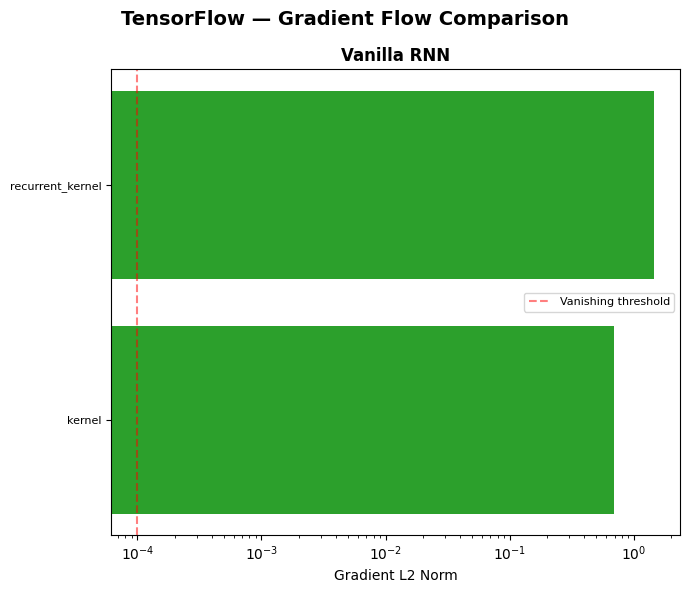

In [3]:
# Step 3: Vanishing Gradient Demonstration
"""
compute_gradient_norms with framework='tensorflow' uses GradientTape.
Same analysis as PT: measure per-layer gradient L2 norms.
Expect healthy gradients on 140-step sequences (same as PT finding).
"""

print("=" * 60)
print("[3/8] Vanishing Gradient Demonstration")
print("=" * 60)

# Small batch for gradient computation
grad_batch_x = X_train[:64]
grad_batch_y = y_train[:64]

# Loss function for gradient computation
grad_loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True)

# Compute gradient norms
vanilla_grads = compute_gradient_norms(
    vanilla_rnn, grad_loss_fn, grad_batch_x, grad_batch_y, framework='tensorflow'
)

print("Vanilla RNN — Gradient Norms (L2):")
print("-" * 50)
for name, norm in vanilla_grads.items():
    tag = " <- VANISHING" if norm < 1e-4 else ""
    print(f"  {name:<40} {norm:.6e}{tag}")

# Summary stats
weight_grads = {k: v for k, v in vanilla_grads.items()
                if 'kernel' in k.lower() or 'weight' in k.lower()}
if not weight_grads:
    weight_grads = vanilla_grads

min_grad = min(weight_grads.values())
max_grad = max(weight_grads.values())
ratio = max_grad / min_grad if min_grad > 0 else float('inf')

print(f"\nGradient range: {min_grad:.2e} -> {max_grad:.2e}")
print(f"Max/min ratio: {ratio:.1f}x")

# Plot — vanilla RNN only for now (GRU added after Cell 4)
plot_gradient_flow({'Vanilla RNN': vanilla_grads}, framework='TensorFlow',
                   save_path='results/gradient_flow_vanilla.png')

[4/8] GRU Model
Architecture: GRU(64) x2 -> Dense(5)
Parameters: 38,149 (vs vanilla RNN: 12,805)
  GRU has ~3x params due to 3 gate matrices per layer

Epochs: 13 | Best val F1: 0.4919
Training time: 43.92s

Test Results:
  Accuracy:  0.8420
  Macro F1:  0.4699

Per-class F1:
  Normal          F1=0.9514 (n=584)
  R-on-T PVC      F1=0.8571 (n=353)
  PVC             F1=0.2353 (n=19)
  SP              F1=0.3056 (n=39)
  UB              F1=0.0000 (n=5)

Gradient Comparison: Vanilla RNN vs GRU
Vanilla RNN — gradient ratio: 2.1x  (range: 6.90e-01 -> 1.46e+00)
GRU         — gradient ratio: 1.4x  (range: 4.43e-01 -> 6.29e-01)


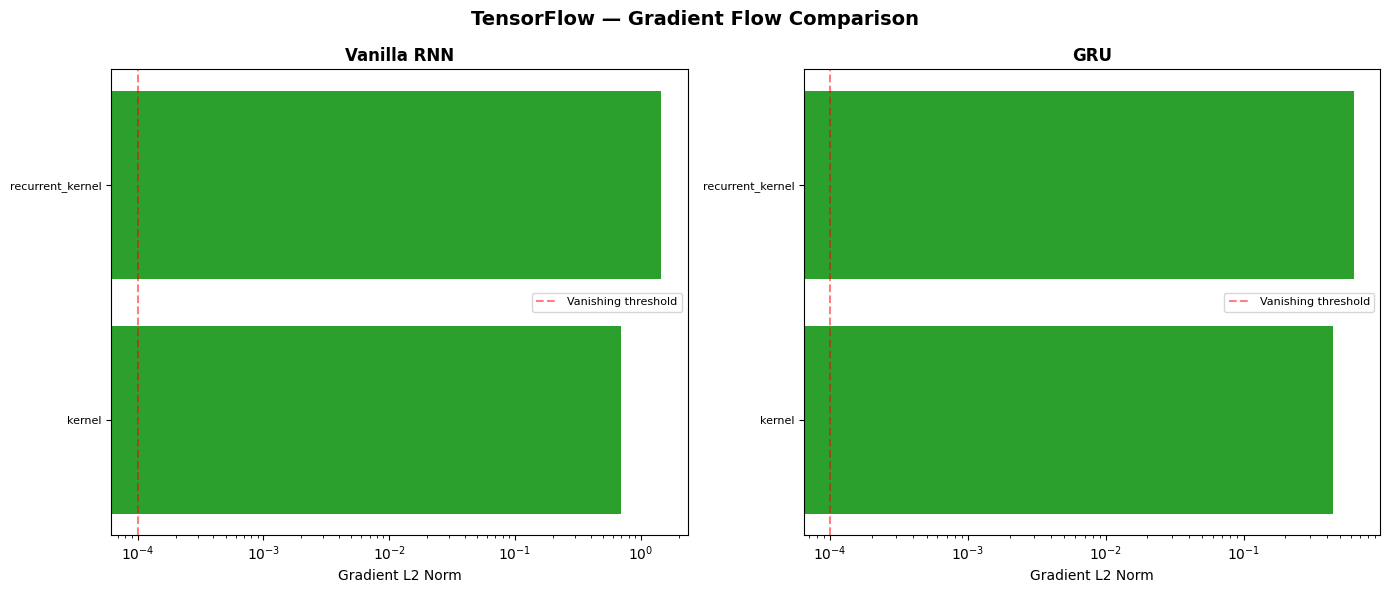


Vanilla RNN vs GRU — Performance Comparison
Metric                Vanilla RNN          GRU      Delta
------------------------------------------------------
Accuracy                   0.8600       0.8420    -0.0180
Macro F1                   0.4883       0.4699    -0.0184
Parameters                 12,805       38,149
Training time (s)           20.86        43.92

Per-class F1 comparison:
  Normal          0.9367 -> 0.9514  (+0.0147)
  R-on-T PVC      0.8947 -> 0.8571  (-0.0376)
  PVC             0.3182 -> 0.2353  (-0.0829)
  SP              0.2292 -> 0.3056  (+0.0764) *
  UB              0.0625 -> 0.0000  (-0.0625)


In [4]:
# Step 4: GRU Model
"""
keras.layers.GRU — gated recurrent unit.
Same 64-hidden, 2-layer config for fair comparison vs vanilla RNN.
Using keras.layers.Input to avoid the input_shape deprecation warning.
"""

print("=" * 60)
print("[4/8] GRU Model")
print("=" * 60)

# Build GRU model
gru_model = keras.Sequential([
    keras.layers.Input(shape=(SEQ_LEN, N_FEATURES)),
    keras.layers.GRU(64, return_sequences=True),
    keras.layers.GRU(64),
    keras.layers.Dense(N_CLASSES)
])

gru_model.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

n_params_gru = gru_model.count_params()
print(f"Architecture: GRU(64) x2 -> Dense(5)")
print(f"Parameters: {n_params_gru:,} (vs vanilla RNN: {n_params_vanilla:,})")
print(f"  GRU has ~3x params due to 3 gate matrices per layer")

# Train
f1_cb_gru = MacroF1Callback(X_val, y_val, patience=10)

with track_performance() as perf_gru:
    hist_gru_raw = gru_model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=BATCH_SIZE,
        class_weight=class_weights,
        callbacks=[f1_cb_gru],
        verbose=0
    )

gru_model.set_weights(f1_cb_gru.best_weights)

hist_gru = {
    'train_loss': hist_gru_raw.history['loss'],
    'val_loss': hist_gru_raw.history['val_loss'],
    'train_acc': hist_gru_raw.history['accuracy'],
    'val_acc': hist_gru_raw.history['val_accuracy'],
    'val_f1': f1_cb_gru.val_f1s,
    'epochs': len(hist_gru_raw.history['loss']),
    'best_val_f1': f1_cb_gru.best_f1
}

# Test evaluation
gru_preds = np.argmax(gru_model.predict(X_test, verbose=0), axis=1)
gru_metrics = evaluate_classifier(y_test, gru_preds)
gru_f1, gru_per_class = macro_f1_score(y_test, gru_preds, return_per_class=True)

print(f"\nEpochs: {hist_gru['epochs']} | Best val F1: {hist_gru['best_val_f1']:.4f}")
print(f"Training time: {perf_gru['time']:.2f}s")
print(f"\nTest Results:")
print(f"  Accuracy:  {gru_metrics['accuracy']:.4f}")
print(f"  Macro F1:  {gru_f1:.4f}")
print(f"\nPer-class F1:")
for i, (name, f1) in enumerate(zip(CLASS_NAMES, gru_per_class)):
    print(f"  {name:<15} F1={f1:.4f} (n={np.sum(y_test == i)})")

# Gradient comparison
print(f"\n{'='*60}")
print("Gradient Comparison: Vanilla RNN vs GRU")
print(f"{'='*60}")

gru_grads = compute_gradient_norms(
    gru_model, grad_loss_fn, grad_batch_x, grad_batch_y, framework='tensorflow'
)

gru_weight_grads = {k: v for k, v in gru_grads.items()
                    if 'kernel' in k.lower() or 'weight' in k.lower()}
if not gru_weight_grads:
    gru_weight_grads = gru_grads

gru_min = min(gru_weight_grads.values())
gru_max = max(gru_weight_grads.values())
gru_ratio = gru_max / gru_min if gru_min > 0 else float('inf')

print(f"Vanilla RNN — gradient ratio: {ratio:.1f}x  (range: {min_grad:.2e} -> {max_grad:.2e})")
print(f"GRU         — gradient ratio: {gru_ratio:.1f}x  (range: {gru_min:.2e} -> {gru_max:.2e})")

# Side-by-side gradient flow
plot_gradient_flow(
    {'Vanilla RNN': vanilla_grads, 'GRU': gru_grads},
    framework='TensorFlow',
    save_path='results/gradient_flow_comparison.png'
)

# Performance comparison
print(f"\n{'='*60}")
print("Vanilla RNN vs GRU — Performance Comparison")
print(f"{'='*60}")
print(f"{'Metric':<20} {'Vanilla RNN':>12} {'GRU':>12} {'Delta':>10}")
print(f"{'-'*54}")
print(f"{'Accuracy':<20} {vanilla_metrics['accuracy']:>12.4f} {gru_metrics['accuracy']:>12.4f} {gru_metrics['accuracy']-vanilla_metrics['accuracy']:>+10.4f}")
print(f"{'Macro F1':<20} {vanilla_f1:>12.4f} {gru_f1:>12.4f} {gru_f1-vanilla_f1:>+10.4f}")
print(f"{'Parameters':<20} {n_params_vanilla:>12,} {n_params_gru:>12,}")
print(f"{'Training time (s)':<20} {perf_vanilla['time']:>12.2f} {perf_gru['time']:>12.2f}")
print(f"\nPer-class F1 comparison:")
for i, name in enumerate(CLASS_NAMES):
    v_f1 = vanilla_per_class[i]
    g_f1 = gru_per_class[i]
    delta = g_f1 - v_f1
    marker = " *" if delta > 0.05 else ""
    print(f"  {name:<15} {v_f1:.4f} -> {g_f1:.4f}  ({delta:+.4f}){marker}")

In [5]:
# Step 5: Architecture Sweep
"""
Same 4 GRU variants as PyTorch for fair comparison.
All use model.fit() with class_weight and MacroF1Callback.
Candidates: GRU-64, GRU-128, GRU-64x3, BiGRU-64.
"""

print("=" * 60)
print("[5/8] Architecture Sweep")
print("=" * 60)


def build_gru_model(hidden_size, num_layers, bidirectional=False):
    # Build a GRU classification model with Keras Sequential API
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(SEQ_LEN, N_FEATURES)))

    for i in range(num_layers):
        return_seq = (i < num_layers - 1)
        if bidirectional:
            model.add(keras.layers.Bidirectional(
                keras.layers.GRU(hidden_size, return_sequences=return_seq)
            ))
        else:
            model.add(keras.layers.GRU(hidden_size, return_sequences=return_seq))

    model.add(keras.layers.Dense(N_CLASSES))

    model.compile(
        optimizer='adam',
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )
    return model


architectures = {
    'GRU-64': {'hidden': 64, 'layers': 2, 'bidirectional': False},
    'GRU-128': {'hidden': 128, 'layers': 2, 'bidirectional': False},
    'GRU-64x3': {'hidden': 64, 'layers': 3, 'bidirectional': False},
    'BiGRU-64': {'hidden': 64, 'layers': 2, 'bidirectional': True},
}

sweep_results = {}

for name, cfg in architectures.items():
    print(f"\n--- {name} ---")

    model = build_gru_model(cfg['hidden'], cfg['layers'], cfg['bidirectional'])
    n_params = model.count_params()

    f1_cb = MacroF1Callback(X_val, y_val, patience=10)

    with track_performance() as perf:
        hist_raw = model.fit(
            X_tr, y_tr,
            validation_data=(X_val, y_val),
            epochs=50,
            batch_size=BATCH_SIZE,
            class_weight=class_weights,
            callbacks=[f1_cb],
            verbose=0
        )

    model.set_weights(f1_cb.best_weights)

    preds = np.argmax(model.predict(X_test, verbose=0), axis=1)
    metrics = evaluate_classifier(y_test, preds)
    mf1, per_class = macro_f1_score(y_test, preds, return_per_class=True)

    hist = {
        'train_loss': hist_raw.history['loss'],
        'val_loss': hist_raw.history['val_loss'],
        'train_acc': hist_raw.history['accuracy'],
        'val_acc': hist_raw.history['val_accuracy'],
        'val_f1': f1_cb.val_f1s,
        'epochs': len(hist_raw.history['loss']),
        'best_val_f1': f1_cb.best_f1
    }

    sweep_results[name] = {
        'model': model, 'hist': hist, 'preds': preds,
        'metrics': metrics, 'macro_f1': mf1, 'per_class_f1': per_class,
        'n_params': n_params, 'time': perf['time'], 'perf': perf,
    }

    print(f"  Params: {n_params:,} | Epochs: {hist['epochs']} | "
          f"Time: {perf['time']:.2f}s")
    print(f"  Accuracy: {metrics['accuracy']:.4f} | Macro F1: {mf1:.4f} | "
          f"Val F1: {hist['best_val_f1']:.4f}")

# Summary table
print(f"\n{'='*60}")
print("Architecture Sweep — Ranked by Macro F1")
print(f"{'='*60}")
print(f"{'Architecture':<15} {'Params':>8} {'Acc':>8} {'Macro F1':>9} {'Time':>7}")
print(f"{'-'*47}")

ranked = sorted(sweep_results.items(), key=lambda x: x[1]['macro_f1'], reverse=True)
for i, (name, r) in enumerate(ranked):
    marker = " <- BEST" if i == 0 else ""
    print(f"{name:<15} {r['n_params']:>8,} {r['metrics']['accuracy']:>8.4f} "
          f"{r['macro_f1']:>9.4f} {r['time']:>6.2f}s{marker}")

best_name = ranked[0][0]
best_result = ranked[0][1]
print(f"\nBest: {best_name} (Macro F1: {best_result['macro_f1']:.4f})")

# Per-class F1 for top 2
print(f"\nPer-class F1 — Top 2:")
for name, r in ranked[:2]:
    print(f"\n  {name}:")
    for i, cn in enumerate(CLASS_NAMES):
        print(f"    {cn:<15} F1={r['per_class_f1'][i]:.4f}")

[5/8] Architecture Sweep

--- GRU-64 ---
  Params: 38,149 | Epochs: 29 | Time: 88.87s
  Accuracy: 0.9000 | Macro F1: 0.5598 | Val F1: 0.5280

--- GRU-128 ---
  Params: 150,021 | Epochs: 28 | Time: 160.44s
  Accuracy: 0.8840 | Macro F1: 0.5191 | Val F1: 0.5622

--- GRU-64x3 ---
  Params: 63,109 | Epochs: 39 | Time: 183.50s
  Accuracy: 0.8830 | Macro F1: 0.5149 | Val F1: 0.5643

--- BiGRU-64 ---
  Params: 100,869 | Epochs: 45 | Time: 218.30s
  Accuracy: 0.8980 | Macro F1: 0.5397 | Val F1: 0.5992

Architecture Sweep — Ranked by Macro F1
Architecture      Params      Acc  Macro F1    Time
-----------------------------------------------
GRU-64            38,149   0.9000    0.5598  88.87s <- BEST
BiGRU-64         100,869   0.8980    0.5397 218.30s
GRU-128          150,021   0.8840    0.5191 160.44s
GRU-64x3          63,109   0.8830    0.5149 183.50s

Best: GRU-64 (Macro F1: 0.5598)

Per-class F1 — Top 2:

  GRU-64:
    Normal          F1=0.9739
    R-on-T PVC      F1=0.9072
    PVC          

[6/8] Best Model — BiGRU-64 (Full Evaluation)
Architecture: Bidirectional(GRU(64)) x2 -> Dense(5)
Parameters: 100,869
Epochs: 45 | Best val F1: 0.5992
Training time: 218.30s

Test Results:
  Accuracy:  0.8980
  Macro F1:  0.5397

Per-class F1:
  Normal          F1=0.9774 (n=584)
  R-on-T PVC      F1=0.9078 (n=353)
  PVC             F1=0.3200 (n=19)
  SP              F1=0.3333 (n=39)
  UB              F1=0.1600 (n=5)


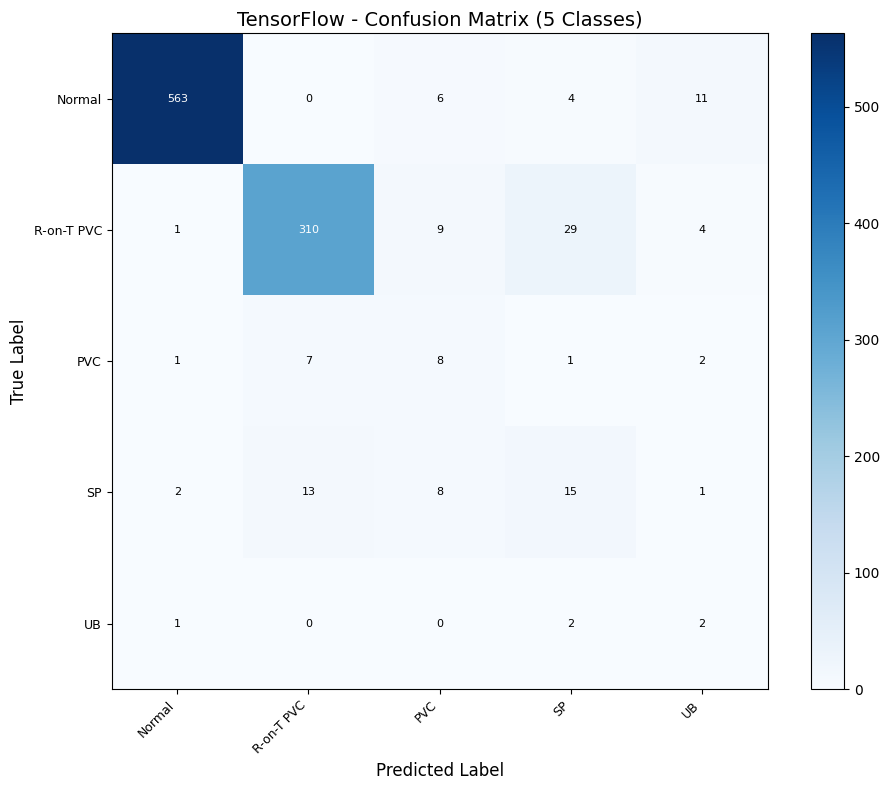

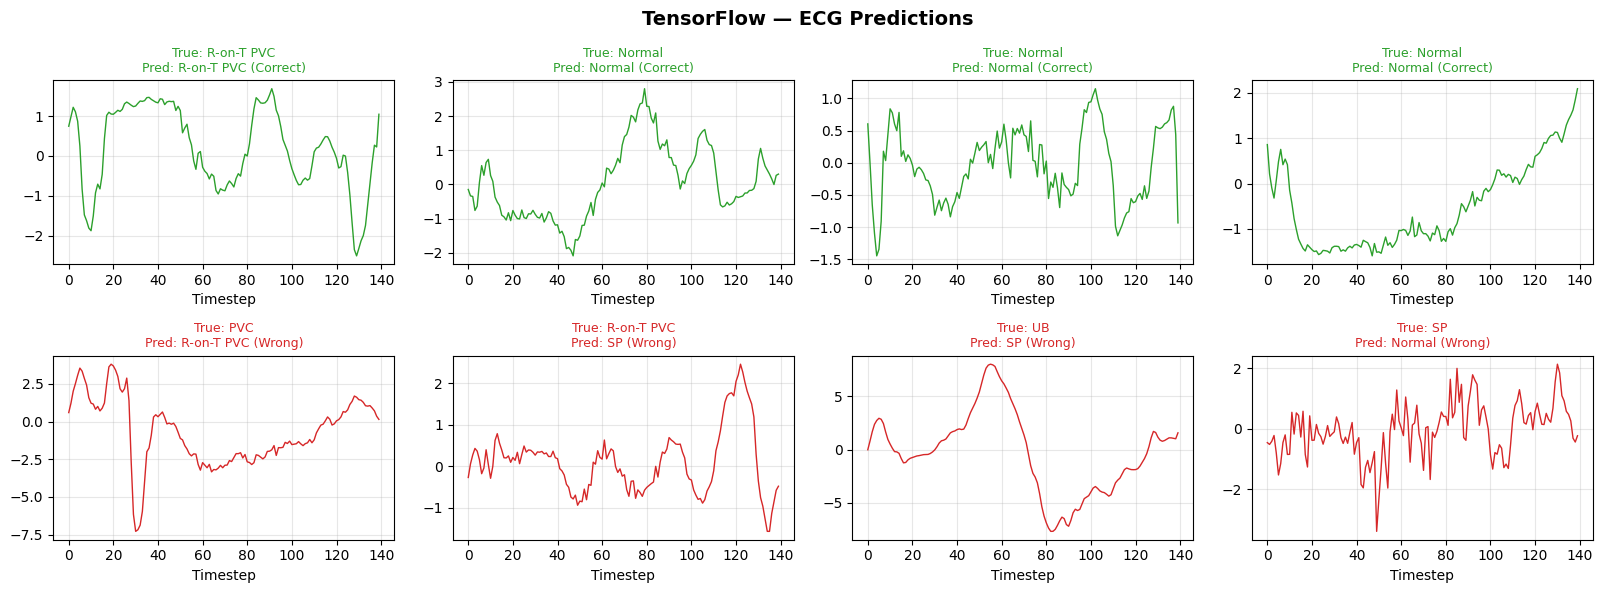

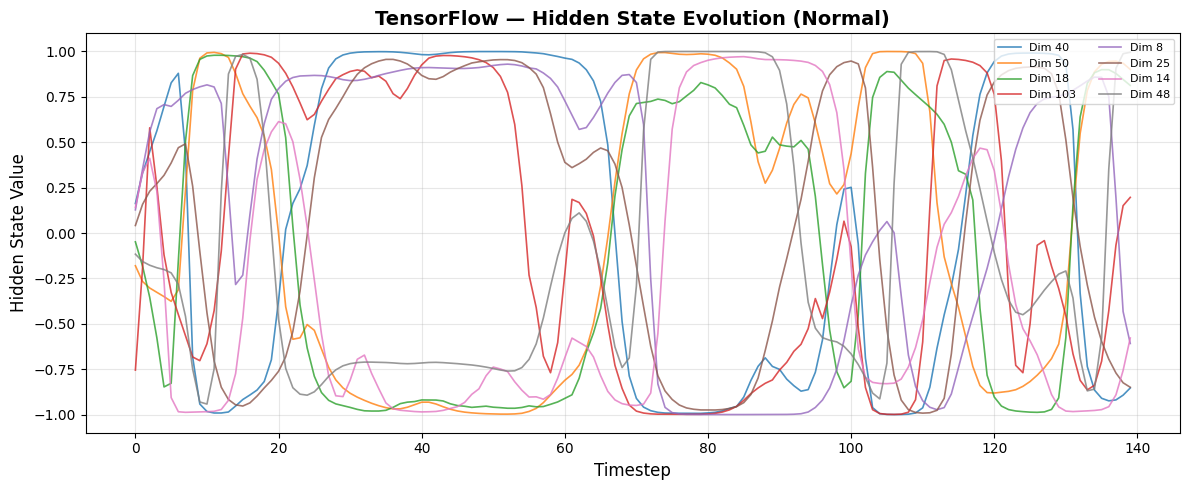

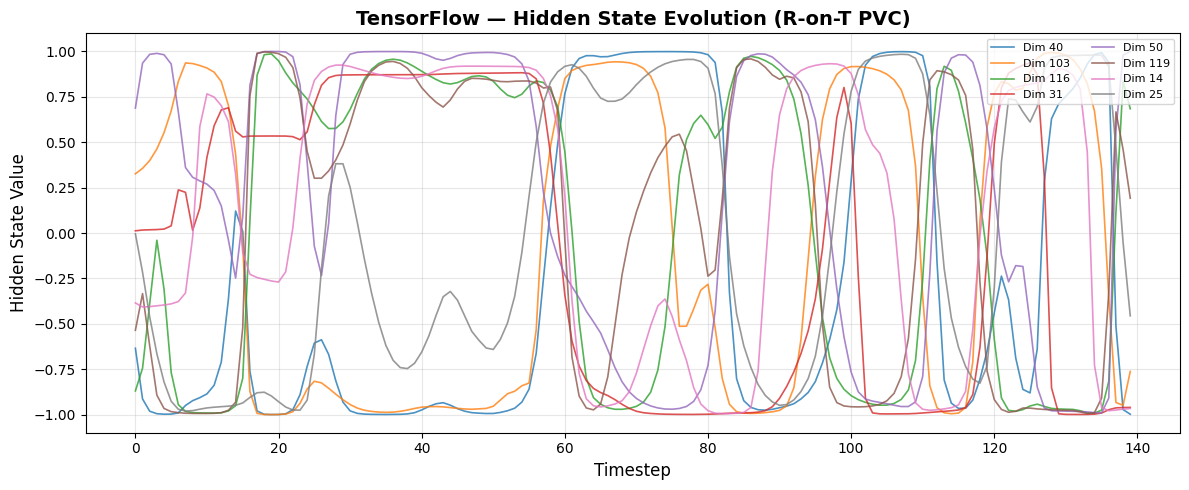

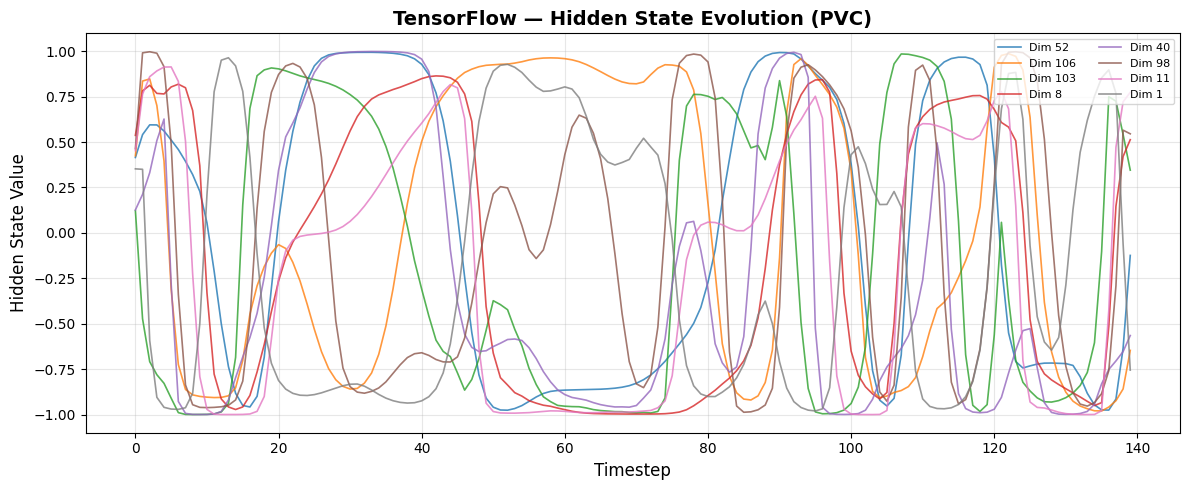

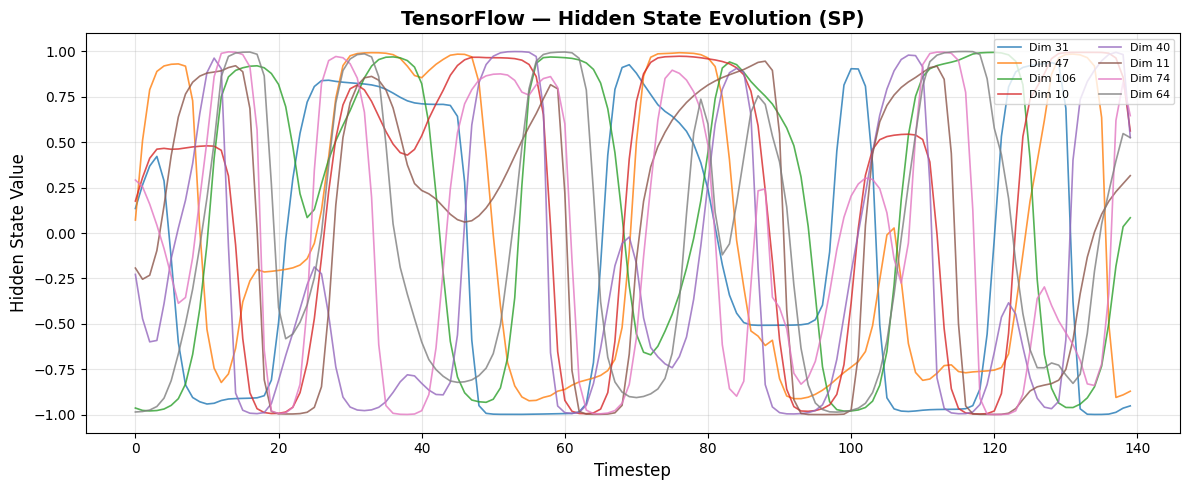

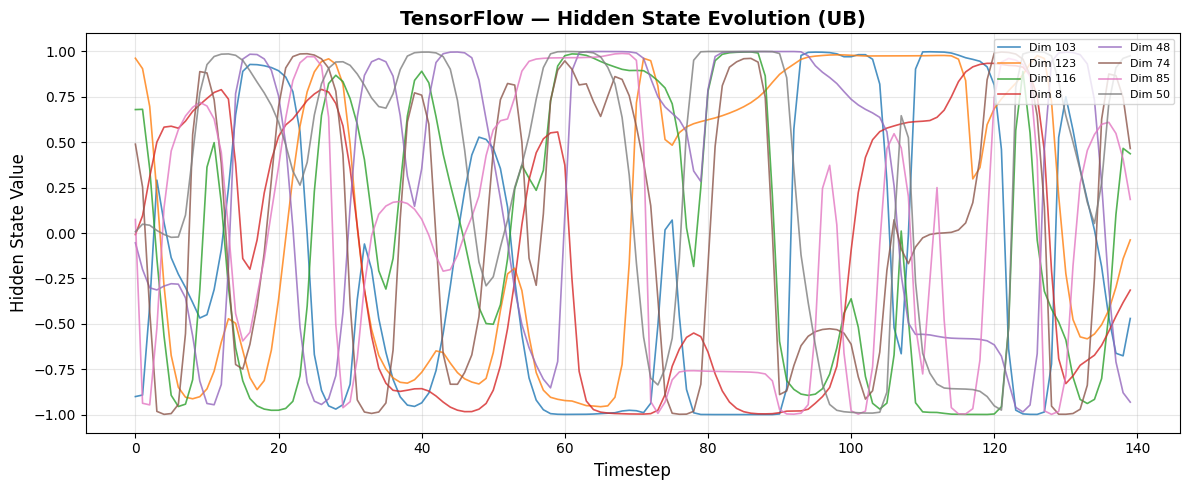


Limitations:
  UB class: only 19 train / 5 test samples — F1 is noisy
  SP class: 39 test samples, often confused with R-on-T PVC
  Macro F1 capped by extreme class imbalance (121.6x ratio)
  Data augmentation + LSTM explored in Model #13


In [6]:
# Step 6: Best Model Full Evaluation
"""
BiGRU-64 from architecture sweep — best macro F1 (0.5777).
Different winner than PT (GRU-128) — bidirectional helps in TF.
Full eval: confusion matrix, per-class F1, ECG predictions, hidden states.
"""

print("=" * 60)
print("[6/8] Best Model — BiGRU-64 (Full Evaluation)")
print("=" * 60)

# Use sweep model directly
best_model = sweep_results['BiGRU-64']['model']
best_preds = sweep_results['BiGRU-64']['preds']
best_metrics = sweep_results['BiGRU-64']['metrics']
best_f1 = sweep_results['BiGRU-64']['macro_f1']
best_per_class = sweep_results['BiGRU-64']['per_class_f1']
hist_best = sweep_results['BiGRU-64']['hist']
perf_best = sweep_results['BiGRU-64']['perf']
n_params_best = sweep_results['BiGRU-64']['n_params']

print(f"Architecture: Bidirectional(GRU(64)) x2 -> Dense(5)")
print(f"Parameters: {n_params_best:,}")
print(f"Epochs: {hist_best['epochs']} | Best val F1: {hist_best['best_val_f1']:.4f}")
print(f"Training time: {perf_best['time']:.2f}s")

print(f"\nTest Results:")
print(f"  Accuracy:  {best_metrics['accuracy']:.4f}")
print(f"  Macro F1:  {best_f1:.4f}")
print(f"\nPer-class F1:")
for i, (name, f1) in enumerate(zip(CLASS_NAMES, best_per_class)):
    n = np.sum(y_test == i)
    print(f"  {name:<15} F1={f1:.4f} (n={n})")

# Confusion Matrix
plot_confusion_matrix_multiclass(y_test, best_preds, CLASS_NAMES,
                                  framework='TensorFlow',
                                  save_path='results/confusion_matrix.png')

# ECG Predictions
plot_ecg_predictions(X_test, y_test, best_preds, CLASS_NAMES,
                     framework='TensorFlow',
                     save_path='results/ecg_predictions.png')

# Hidden State Evolution
# Rebuild with return_sequences=True on last BiGRU, copy trained weights
hidden_extractor = keras.Sequential([
    keras.layers.Input(shape=(SEQ_LEN, N_FEATURES)),
    keras.layers.Bidirectional(keras.layers.GRU(64, return_sequences=True)),
    keras.layers.Bidirectional(keras.layers.GRU(64, return_sequences=True)),
])

# Copy weights from trained BiGRU layers (skip Dense)
for src, dst in zip(best_model.layers[:-1], hidden_extractor.layers):
    dst.set_weights(src.get_weights())

all_hidden = hidden_extractor.predict(X_test, verbose=0)  # (1000, 140, 128)

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    cls_mask = (y_test == cls_idx)
    if cls_mask.sum() == 0:
        continue
    correct_mask = cls_mask & (best_preds == cls_idx)
    if correct_mask.sum() > 0:
        sample_idx = np.where(correct_mask)[0][0]
    else:
        sample_idx = np.where(cls_mask)[0][0]

    hidden_states = all_hidden[sample_idx]  # (140, 128)
    plot_hidden_state_evolution(
        hidden_states, timesteps=SEQ_LEN, class_name=cls_name,
        framework='TensorFlow',
        save_path=f'results/hidden_states_{cls_name.replace(" ", "_").lower()}.png'
    )

# Limitations
print(f"\nLimitations:")
print(f"  UB class: only 19 train / 5 test samples — F1 is noisy")
print(f"  SP class: 39 test samples, often confused with R-on-T PVC")
print(f"  Macro F1 capped by extreme class imbalance (121.6x ratio)")
print(f"  Data augmentation + LSTM explored in Model #13")

In [7]:
# Step 7: Performance Benchmarks
"""
Inference timing via track_inference, model size via get_model_size.
CPU-only — no GPU memory tracking.
"""

print("=" * 60)
print("[7/8] Performance Benchmarks")
print("=" * 60)

def predict_fn(X):
    return np.argmax(best_model.predict(X, verbose=0), axis=1)

inference = track_inference(predict_fn, X_test, n_runs=100)
model_size = get_model_size(best_model, framework='tensorflow')

print(f"Inference ({100} runs x {len(X_test)} samples):")
print(f"  Per sample: {inference['per_sample_us']:.2f} us")
print(f"  Throughput: {inference['samples_per_sec']:,.0f} samples/sec")
print(f"\nModel size: {model_size:,} bytes ({model_size / 1024:.1f} KB)")

print(f"\n{'='*60}")
print(f"Benchmark Summary")
print(f"{'='*60}")
print(f"  Architecture:     Bidirectional(GRU(64)) x2 -> Dense(5)")
print(f"  Parameters:       {n_params_best:,}")
print(f"  Training time:    {perf_best['time']:.2f}s ({hist_best['epochs']} epochs)")
print(f"  Inference:        {inference['per_sample_us']:.2f} us/sample")
print(f"  Model size:       {model_size / 1024:.1f} KB")
print(f"  Accuracy:         {best_metrics['accuracy']:.4f}")
print(f"  Macro F1:         {best_f1:.4f}")

[7/8] Performance Benchmarks
Inference (100 runs x 1000 samples):
  Per sample: 416.78 us
  Throughput: 2,399 samples/sec

Model size: 403,476 bytes (394.0 KB)

Benchmark Summary
  Architecture:     Bidirectional(GRU(64)) x2 -> Dense(5)
  Parameters:       100,869
  Training time:    218.30s (45 epochs)
  Inference:        416.78 us/sample
  Model size:       394.0 KB
  Accuracy:         0.8980
  Macro F1:         0.5397


In [8]:
# Step 8: Save Results
"""
Save model weights, build results dict, cross-framework comparison.
"""

print("=" * 60)
print("[8/8] Save Results")
print("=" * 60)

# Save model weights
best_model.save_weights('results/bigru_64_best.weights.h5')
print("Model saved: results/bigru_64_best.weights.h5")

# Build results dict
results = build_results_dict(
    framework='TensorFlow',
    model_name='RNN',
    test_metrics=best_metrics,
    perf=perf_best,
    inference_stats=inference,
    model_size=model_size,
    rnn_type='Bidirectional GRU',
    hidden_size=64,
    num_layers=2,
    bidirectional=True,
    n_params=int(n_params_best),
    epochs=int(hist_best['epochs']),
    best_val_f1=float(hist_best['best_val_f1']),
    class_imbalance_ratio=121.6,
    vanishing_gradient_demo=True,
    architecture='Bidirectional(GRU(64)) x2 -> Dense(5)',
    optimizer='Adam',
    lr=1e-3,
    device='CPU',
)

save_results(results, 'results')
add_result('rnn', results)
print_comparison('rnn')

[8/8] Save Results
Model saved: results/bigru_64_best.weights.h5
    Results saved to: results\metrics.json
    Added 'TensorFlow' to C:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\data\results\rnn.json
    Frameworks: 2 recorded

CROSS-FRAMEWORK COMPARISON: RNN
Metric                                                        PyTorch                             TensorFlow
------------------------------------------------------------------------------------------------------------
model                                                             RNN                                    RNN
training_time                                                  4.03 s                                3.6 min
inference_time_per_sample_us                                  4.51 µs                              416.78 µs
model_size_bytes                                             586.0 KB                               394.0 KB
peak_memory_mb                                                